# 🔬 Projet Clustering – M1 Informatique

---

**Auteur :** *NGOM Khadim*  

**Cours :** M1 Informatique – Clustering – Séance 7 évaluée  

---

## 📋 Résumé

Ce notebook constitue le matériel de calcul du projet de clustering. Il suit la méthodologie **CRISP-DM** (Cross-Industry Standard Process for Data Mining) et couvre les étapes suivantes :

1. Chargement et exploration des données
2. Préparation et prétraitement
3. Identification du nombre optimal de clusters
4. Application de l'algorithme de clustering
5. Sélection des variables pertinentes
6. Interprétation et profiling des clusters
7. Sauvegarde du modèle pour le déploiement

---

> **📁 Données :** `dataset_clustering_td7.xlsx` — 5 000 observations × 200 variables

---
## ⚙️ Cellule 1 — Importation des bibliothèques

On importe l'ensemble des bibliothèques nécessaires à l'analyse. Chaque groupe de bibliothèques remplit un rôle spécifique :
- **pandas / numpy** : manipulation des données tabulaires
- **matplotlib / seaborn** : visualisations statiques
- **sklearn** : algorithmes de clustering, métriques d'évaluation et prétraitement
- **scipy** : dendrogrammes pour la CAH
- **joblib** : sauvegarde et rechargement du modèle

In [17]:
# ─────────────────────────────────────────────────────────────
# CELLULE 1 — Importation des bibliothèques
# ─────────────────────────────────────────────────────────────

import warnings
warnings.filterwarnings('ignore')

# Manipulation des données
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# Prétraitement
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score
)

# Sélection de variables
from scipy.stats import f_oneway
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold

# Sauvegarde du modèle
import joblib
import os

# Style global des graphiques
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print("Toutes les bibliothèques ont été importées avec succès.")

Toutes les bibliothèques ont été importées avec succès.


---
## 📂 Cellule 2 — Chargement des données

On charge le fichier Excel `dataset_clustering_td7.xlsx` et on effectue une **première inspection** du jeu de données pour s'assurer que les dimensions et les types de données sont conformes à ce qui est attendu (n = 5 000 observations, p = 200 variables).

In [19]:
# ─────────────────────────────────────────────────────────────
# CELLULE 2 — Chargement des données
# ─────────────────────────────────────────────────────────────

FICHIER = 'dataset_clustering_td7.xlsx'

df_raw = pd.read_excel(FICHIER)

print("═" * 55)
print("  INFORMATIONS GÉNÉRALES SUR LE JEU DE DONNÉES")
print("═" * 55)
print(f"  • Nombre d'observations : {df_raw.shape[0]:,}")
print(f"  • Nombre de variables    : {df_raw.shape[1]:,}")
print("═" * 55)

print("\n Aperçu des 5 premières lignes :")
df_raw.head()

═══════════════════════════════════════════════════════
  INFORMATIONS GÉNÉRALES SUR LE JEU DE DONNÉES
═══════════════════════════════════════════════════════
  • Nombre d'observations : 5,000
  • Nombre de variables    : 200
═══════════════════════════════════════════════════════

 Aperçu des 5 premières lignes :


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,...,x191,x192,x193,x194,x195,x196,x197,x198,x199,x200
0,-0.248535,0.145788,0.715864,0.914395,0.091961,-0.608915,-0.080377,-0.339177,1.231224,0.131632,...,-0.864981,-2.075451,-0.338718,-1.771859,0.100589,-0.664386,-0.506096,-1.321640,-1.351718,-0.481303
1,0.002789,1.112445,-0.883577,1.235890,-1.393756,-1.393730,0.816158,-0.773380,0.409249,-0.780268,...,3.114749,-0.760683,0.109926,1.669901,-0.102156,-0.032618,-1.722300,0.192593,1.075450,0.506329
2,-0.708017,0.705544,-1.341895,-2.040341,0.052162,-0.493972,0.767671,0.916088,-0.485598,-0.060803,...,0.002947,0.207544,0.620534,-2.410022,-1.444543,0.513560,-0.522060,-0.946193,0.212967,0.801792
3,0.830325,1.554153,-1.557530,0.046190,-1.090069,0.856708,0.163534,-0.803240,-0.124234,-0.479818,...,0.031002,-1.008092,1.505604,1.081685,-0.300623,1.176736,0.969504,0.025091,1.586661,1.849862
4,0.979696,-1.198923,-0.115506,0.389813,-0.865552,0.123505,-0.735064,1.394710,-0.306937,-1.115578,...,0.529133,0.281278,-1.092423,1.150125,0.203612,-1.230793,0.382647,0.351172,-0.983286,0.339562


---
## 📊 Cellule 3 — Exploration des données (EDA)

Avant toute modélisation, on réalise une **analyse exploratoire** pour :
- Évaluer la qualité des données (valeurs manquantes)
- Comprendre les types de variables (numériques, catégorielles)
- Observer les distributions et identifier d'éventuels outliers

Cette étape est indispensable pour prendre des décisions éclairées lors du prétraitement.

In [20]:
# ─────────────────────────────────────────────────────────────
# CELLULE 3 — Exploration des données (EDA)
# ─────────────────────────────────────────────────────────────

#  3.1 Types de variables
print("Types de données :")
type_counts = df_raw.dtypes.value_counts()
for dtype, count in type_counts.items():
    print(f"   {str(dtype):<15} → {count} variable(s)")

# 3.2 Valeurs manquantes
print("\n Valeurs manquantes :")
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw)) * 100
missing_df = pd.DataFrame({'Manquants': missing, '% Manquants': missing_pct})
missing_avec = missing_df[missing_df['Manquants'] > 0]

if missing_avec.empty:
    print("  Aucune valeur manquante détectée.")
else:
    print(f"   {len(missing_avec)} variable(s) avec des valeurs manquantes :")
    print(missing_avec.sort_values('% Manquants', ascending=False).head(10))

# 3.3 Statistiques descriptives (sur les 10 premières variables numériques)
print("\n Statistiques descriptives (extrait – 10 premières variables numériques) :")
cols_num = df_raw.select_dtypes(include=[np.number]).columns[:10]
df_raw[cols_num].describe().round(3)

Types de données :
   float64         → 200 variable(s)

 Valeurs manquantes :
  Aucune valeur manquante détectée.

 Statistiques descriptives (extrait – 10 premières variables numériques) :


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10
count,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000
mean,-0.024,-0.009,-0.008,-0.013,0.004,0.004,0.008,-0.008,0.021,-0.008
std,1.001,0.997,1.018,1.012,1.006,0.984,0.991,1.008,0.997,0.986
min,-3.430,-4.199,-3.873,-3.686,-3.116,-3.460,-3.714,-3.569,-3.614,-3.842
25%,-0.707,-0.665,-0.707,-0.707,-0.672,-0.656,-0.658,-0.702,-0.632,-0.658
50%,-0.033,-0.031,0.002,-0.024,0.008,0.001,0.012,-0.015,0.040,0.004
75%,0.653,0.658,0.701,0.679,0.681,0.659,0.671,0.674,0.691,0.642
max,3.551,3.329,3.289,3.654,3.688,3.614,3.676,3.632,3.954,3.279


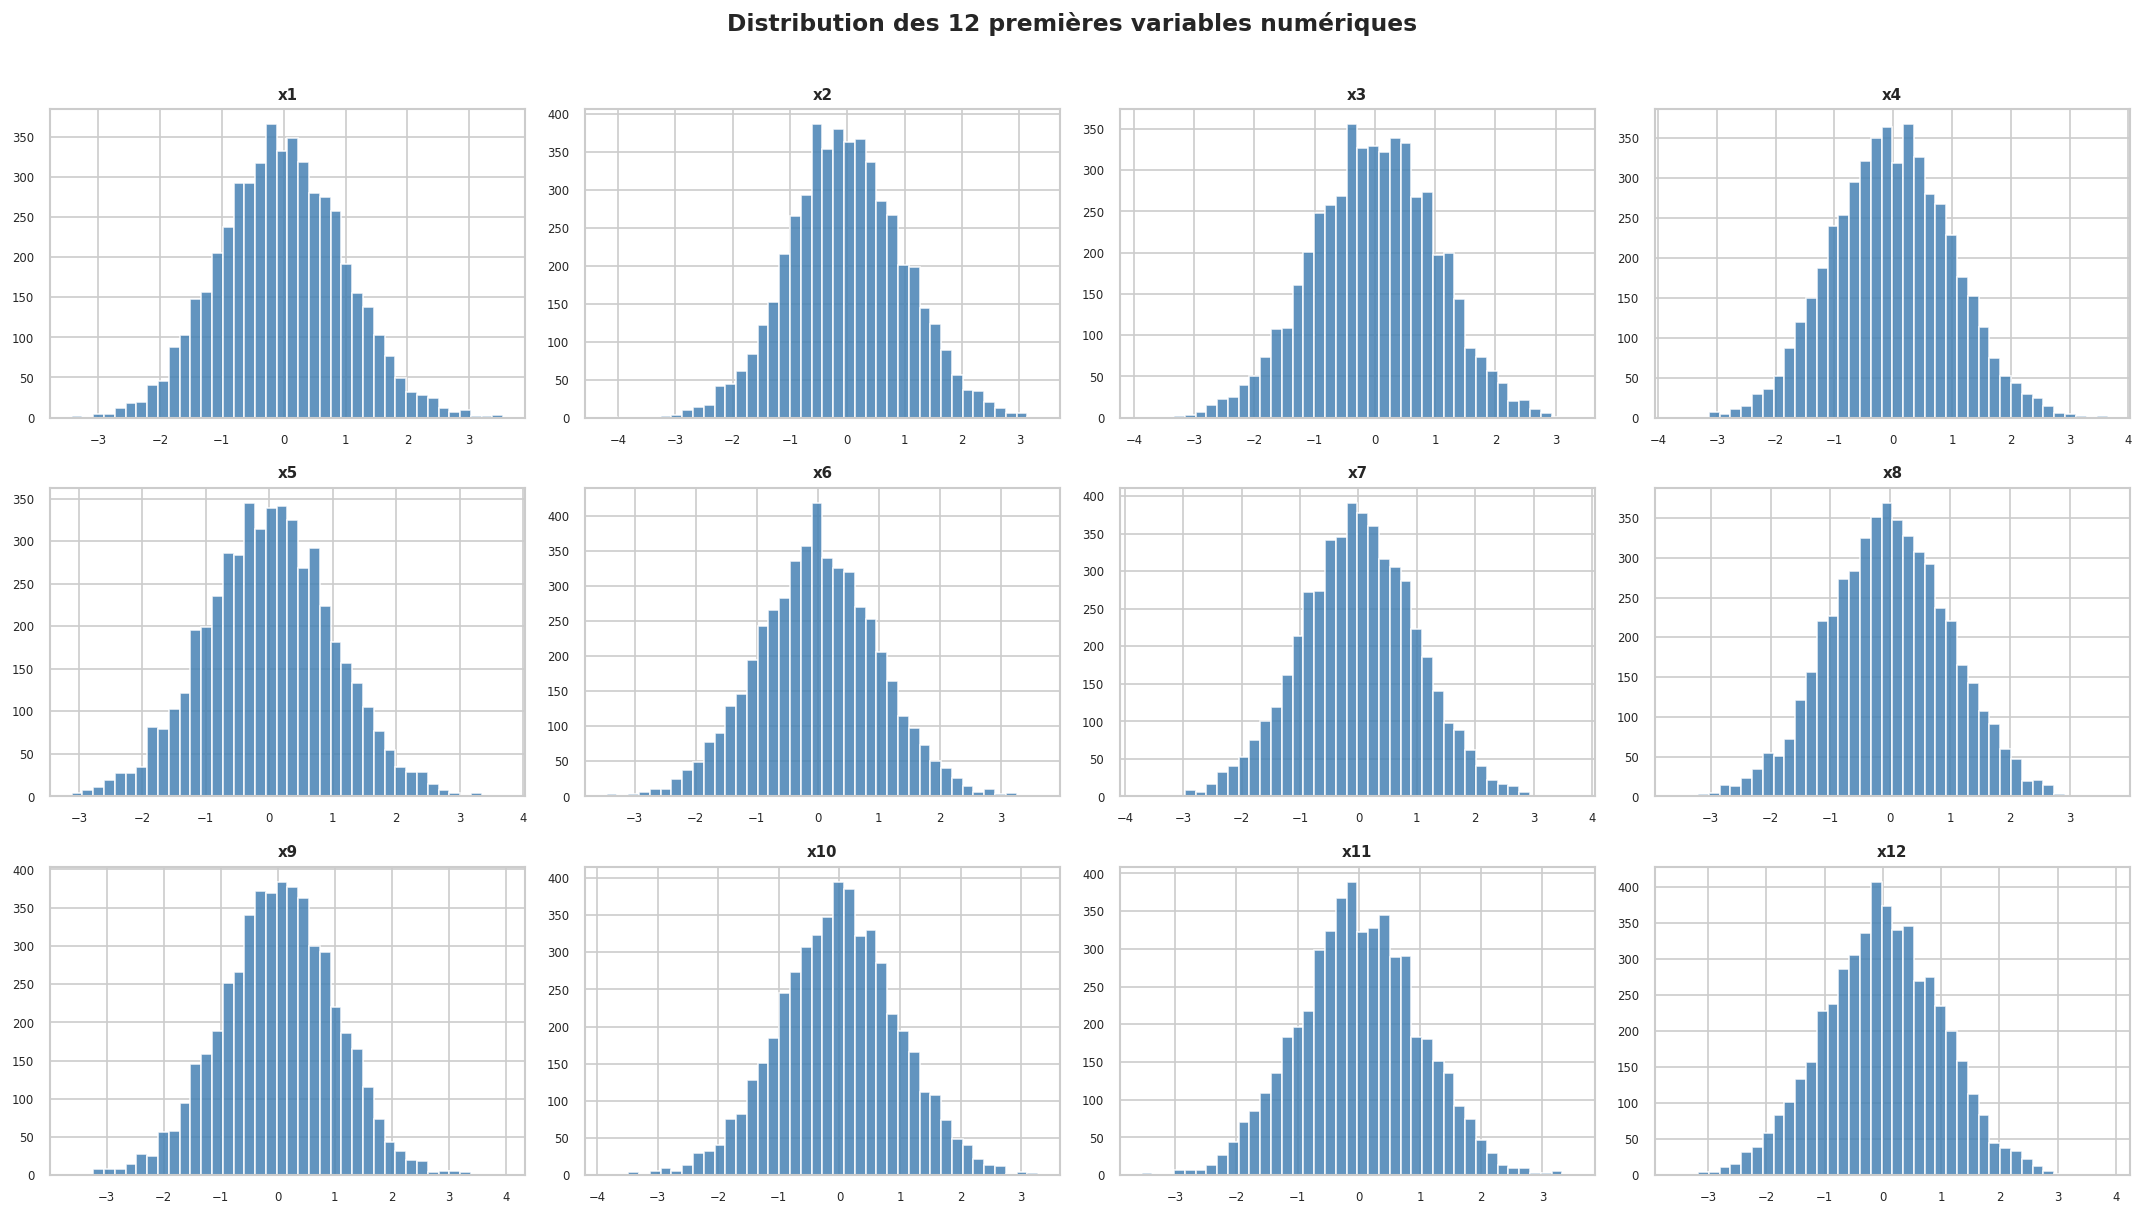

 Figure sauvegardée : figures/distributions.png


In [21]:
# ─────────────────────────────────────────────────────────────
# CELLULE 3b — Visualisation des distributions (extrait)
# ─────────────────────────────────────────────────────────────

import os
os.makedirs('figures', exist_ok=True)

# On visualise les distributions des 12 premières variables numériques
cols_num_all = df_raw.select_dtypes(include=[np.number]).columns
cols_plot = cols_num_all[:12]

fig, axes = plt.subplots(3, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cols_plot):
    axes[i].hist(df_raw[col].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='both', labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribution des 12 premières variables numériques', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/distributions.png', bbox_inches='tight')
plt.show()
print(" Figure sauvegardée : figures/distributions.png")

---
## 🔧 Cellule 4 — Prétraitement des données

Le prétraitement comprend plusieurs étapes essentielles :

1. **Sélection des variables numériques** : les algorithmes de clustering euclidiens opèrent sur des valeurs numériques.
2. **Traitement des valeurs manquantes** : remplacement par la médiane (robuste aux outliers).
3. **Suppression des variables à variance nulle** : ces variables n'apportent aucune information discriminante.
4. **Standardisation (Z-score)** : on centre et réduit chaque variable pour que toutes aient une contribution équivalente dans le calcul des distances.

In [22]:
# ─────────────────────────────────────────────────────────────
# CELLULE 4 — Prétraitement des données
# ─────────────────────────────────────────────────────────────

import os
os.makedirs('figures', exist_ok=True)
os.makedirs('modele', exist_ok=True)

# 4.1 Sélection des variables numériques
df_num = df_raw.select_dtypes(include=[np.number]).copy()
print(f" Variables numériques retenues : {df_num.shape[1]} sur {df_raw.shape[1]}")

# 4.2 Imputation des valeurs manquantes (médiane)
for col in df_num.columns:
    if df_num[col].isnull().any():
        df_num[col].fillna(df_num[col].median(), inplace=True)
print(f" Valeurs manquantes traitées (imputation par médiane).")

# 4.3 Suppression des variables à variance nulle
selector = VarianceThreshold(threshold=0.0)
selector.fit(df_num)
cols_avant = df_num.shape[1]
df_num = df_num.loc[:, selector.get_support()]
cols_apres = df_num.shape[1]
print(f" Variables à variance nulle supprimées : {cols_avant - cols_apres} supprimée(s), {cols_apres} retenue(s).")

#  4.4 Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_num)
df_scaled = pd.DataFrame(X_scaled, columns=df_num.columns)

print(f"\nStandardisation appliquée (moyenne ≈ 0, écart-type ≈ 1).")
print(f"   Forme de la matrice finale : {df_scaled.shape[0]:,} × {df_scaled.shape[1]:,}")

# Sauvegarde du scaler pour le déploiement
joblib.dump(scaler, 'modele/scaler.pkl')
joblib.dump(df_num.columns.tolist(), 'modele/colonnes.pkl')
print("\n Scaler et noms des colonnes sauvegardés dans modele/")

 Variables numériques retenues : 200 sur 200
 Valeurs manquantes traitées (imputation par médiane).
 Variables à variance nulle supprimées : 0 supprimée(s), 200 retenue(s).

Standardisation appliquée (moyenne ≈ 0, écart-type ≈ 1).
   Forme de la matrice finale : 5,000 × 200

 Scaler et noms des colonnes sauvegardés dans modele/


---
## 🔢 Cellule 5 — Réduction dimensionnelle (ACP)

Avec 200 variables, le calcul de clustering est coûteux et soumis à la **malédiction de la dimensionnalité** (les distances tendent à se concentrer dans les hautes dimensions). On applique une **Analyse en Composantes Principales (ACP)** afin de :
- Réduire la dimension tout en conservant l'essentiel de la variance informationnelle
- Accélérer les calculs
- Faciliter la visualisation

On retient le nombre de composantes expliquant **85 % de la variance cumulée**.

 Nombre de composantes retenues : 156
   Variance expliquée cumulée     : 85.1%


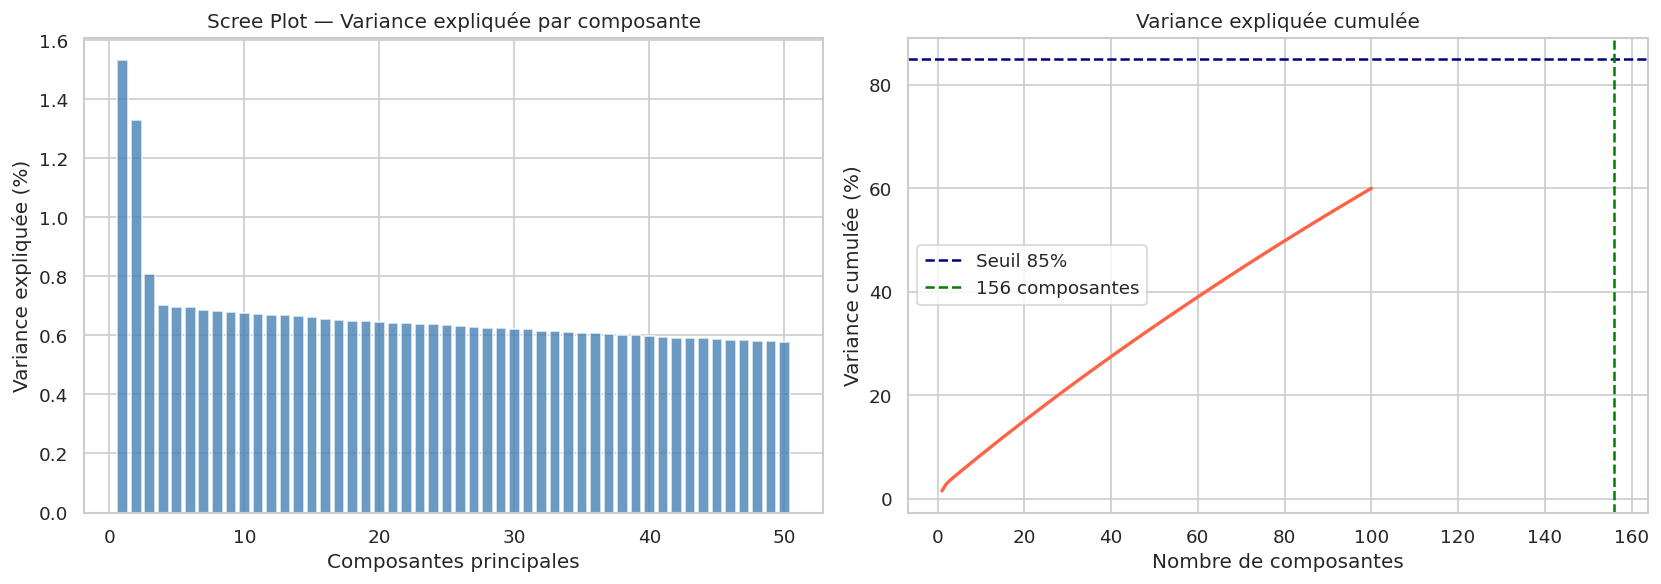


 ACP appliquée : 200 variables → 156 composantes
Modèle PCA sauvegardé dans modele/pca.pkl


In [23]:
# ─────────────────────────────────────────────────────────────
# CELLULE 5 — Réduction dimensionnelle par ACP
# ─────────────────────────────────────────────────────────────

SEUIL_VARIANCE = 0.85  # Conserver 85% de la variance

# ACP complète pour analyser la variance expliquée
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

variance_cumulee = np.cumsum(pca_full.explained_variance_ratio_)
n_composantes = np.searchsorted(variance_cumulee, SEUIL_VARIANCE) + 1

print(f" Nombre de composantes retenues : {n_composantes}")
print(f"   Variance expliquée cumulée     : {variance_cumulee[n_composantes-1]*100:.1f}%")

# Visualisation — Variance expliquée
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, 50 + 1), # Modified to ensure length is 50
            pca_full.explained_variance_ratio_[:50] * 100,
            color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Composantes principales')
axes[0].set_ylabel('Variance expliquée (%)')
axes[0].set_title('Scree Plot — Variance expliquée par composante')

# Variance cumulée
axes[1].plot(range(1, len(variance_cumulee[:100]) + 1), variance_cumulee[:100] * 100,
             color='tomato', linewidth=2, marker='', linestyle='-')
axes[1].axhline(y=85, color='navy', linestyle='--', linewidth=1.5, label='Seuil 85%')
axes[1].axvline(x=n_composantes, color='green', linestyle='--', linewidth=1.5,
                label=f'{n_composantes} composantes')
axes[1].set_xlabel('Nombre de composantes')
axes[1].set_ylabel('Variance cumulée (%)')
axes[1].set_title('Variance expliquée cumulée')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/acp_variance.png', bbox_inches='tight')
plt.show()

# Application de l'ACP avec le nombre de composantes retenu
pca = PCA(n_components=n_composantes, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"\n ACP appliquée : {X_scaled.shape[1]} variables → {n_composantes} composantes")

# Sauvegarde du PCA pour le déploiement
joblib.dump(pca, 'modele/pca.pkl')
print("Modèle PCA sauvegardé dans modele/pca.pkl")

---
## 🔍 Cellule 6 — Identification du nombre optimal de clusters

Déterminer le bon nombre de clusters `k` est l'étape la plus critique du clustering. On utilise ici **trois critères complémentaires** :

| Critère | Interprétation | Valeur optimale |
|---------|---------------|----------------|
| **Inertie (Elbow)** | Somme des distances intra-cluster | Coude de la courbe |
| **Silhouette** | Cohésion interne vs. séparation externe | **Maximum** |
| **Davies-Bouldin** | Rapport similitude inter/intra | **Minimum** |

La **convergence des trois critères** détermine le nombre de clusters retenu.

In [24]:
# ─────────────────────────────────────────────────────────────
# CELLULE 6 — Identification du nombre optimal de clusters
# ─────────────────────────────────────────────────────────────

K_MIN, K_MAX = 2, 10  # Plage de recherche

inertias        = []
silhouettes     = []
davies_bouldins = []
calinski_scores = []
k_values        = range(K_MIN, K_MAX + 1)

print("Calcul des métriques en cours...")
print(f"   (k de {K_MIN} à {K_MAX})\n")

for k in k_values:
    km = KMeans(n_clusters=k, init='k-means++', n_init=15, random_state=42, max_iter=300)
    labels = km.fit_predict(X_pca)

    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))
    davies_bouldins.append(davies_bouldin_score(X_pca, labels))
    calinski_scores.append(calinski_harabasz_score(X_pca, labels))
    print(f"   k={k:2d}  | Inertie={km.inertia_:,.0f}  | Silhouette={silhouettes[-1]:.4f}  | DB={davies_bouldins[-1]:.4f}  | CH={calinski_scores[-1]:,.0f}")

print("\nCalcul terminé.")

Calcul des métriques en cours...
   (k de 2 à 10)

   k= 2  | Inertie=839,535  | Silhouette=0.0139  | DB=8.3499  | CH=70
   k= 3  | Inertie=832,295  | Silhouette=0.0124  | DB=7.7806  | CH=57
   k= 4  | Inertie=827,479  | Silhouette=0.0117  | DB=7.8877  | CH=48
   k= 5  | Inertie=824,597  | Silhouette=0.0096  | DB=8.2780  | CH=40
   k= 6  | Inertie=822,378  | Silhouette=0.0084  | DB=9.0867  | CH=35
   k= 7  | Inertie=820,527  | Silhouette=0.0075  | DB=9.1090  | CH=31
   k= 8  | Inertie=819,272  | Silhouette=0.0072  | DB=9.0290  | CH=28
   k= 9  | Inertie=818,077  | Silhouette=0.0067  | DB=9.2620  | CH=25
   k=10  | Inertie=816,886  | Silhouette=0.0066  | DB=8.9464  | CH=23

Calcul terminé.


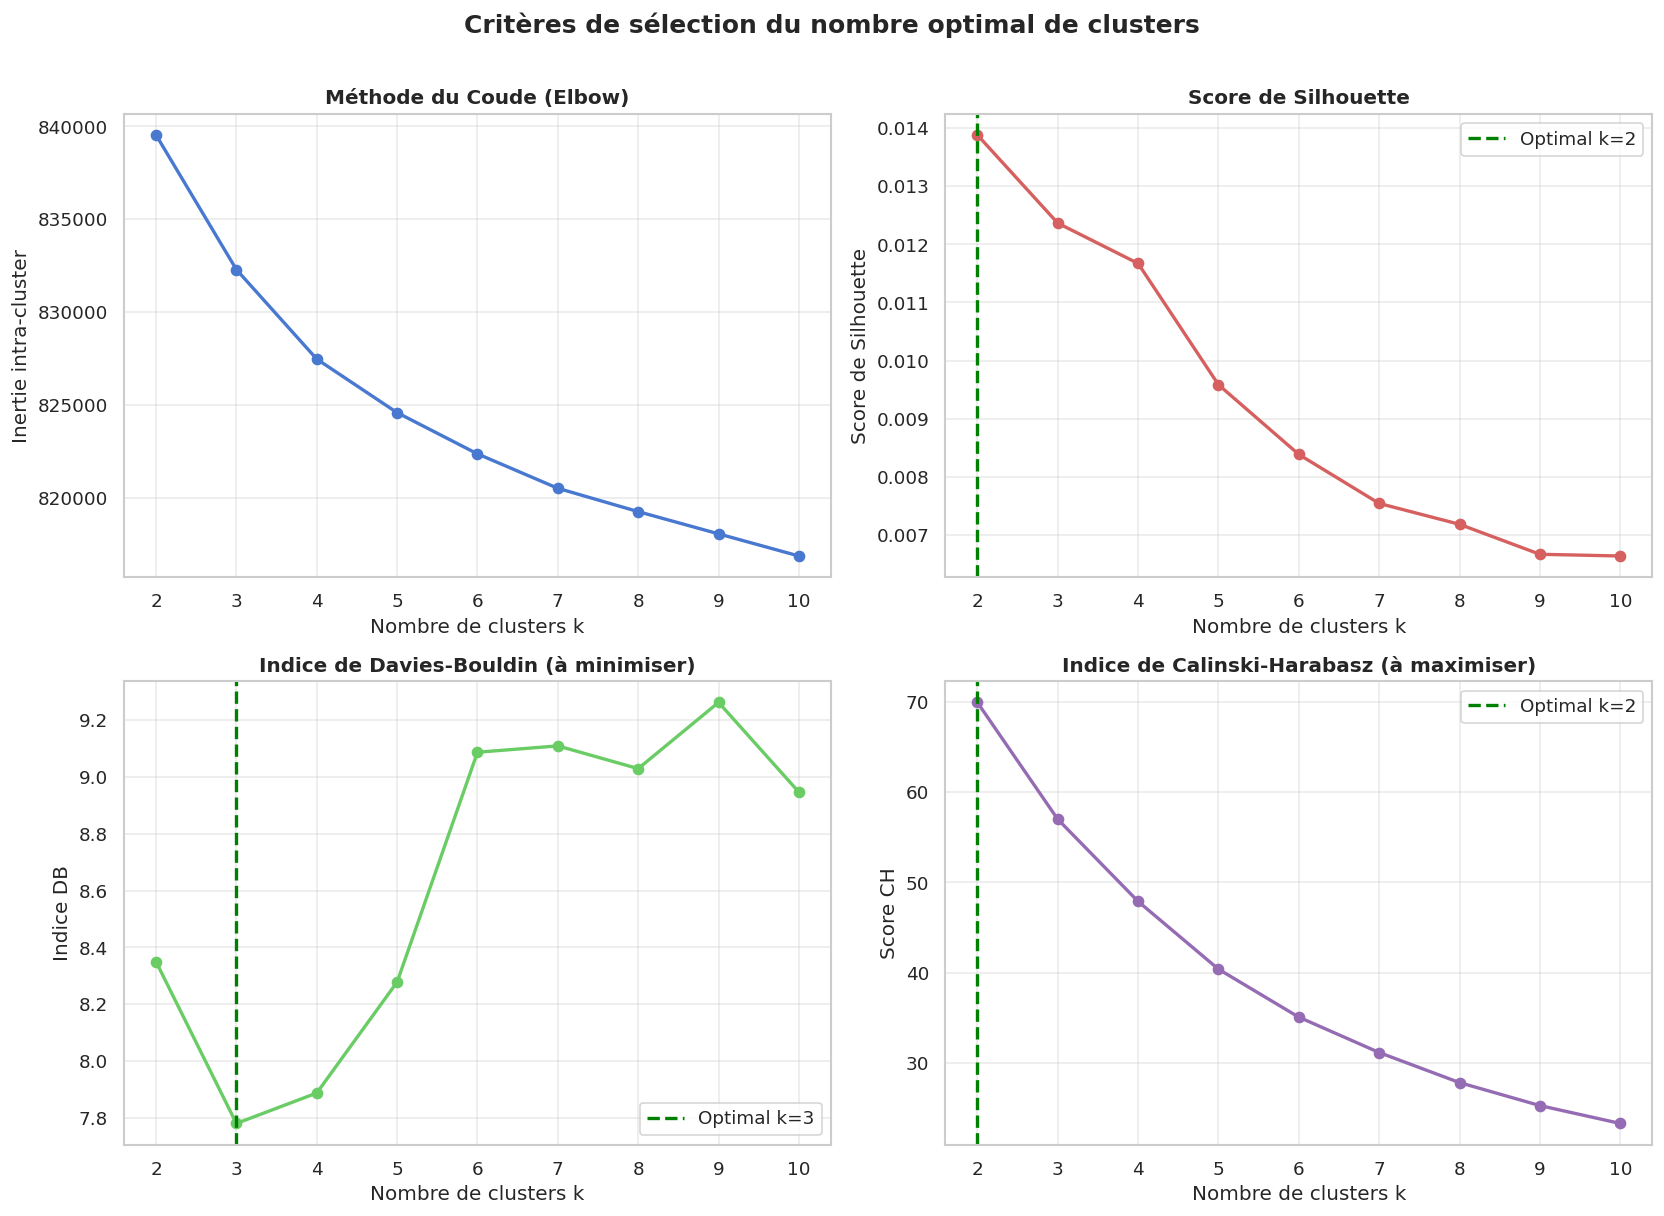


 Récapitulatif des recommandations :
   • Silhouette (max)       → k = 2
   • Davies-Bouldin (min)   → k = 3
   • Calinski-Harabasz (max)→ k = 2


In [25]:
# ─────────────────────────────────────────────────────────────
# CELLULE 6b — Visualisation des métriques
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
k_list = list(k_values)

# Elbow
axes[0, 0].plot(k_list, inertias, 'bo-', linewidth=2, markersize=6)
axes[0, 0].set_title("Méthode du Coude (Elbow)", fontweight='bold')
axes[0, 0].set_xlabel("Nombre de clusters k")
axes[0, 0].set_ylabel("Inertie intra-cluster")
axes[0, 0].grid(True, alpha=0.4)

# Silhouette
k_best_sil = k_list[np.argmax(silhouettes)]
axes[0, 1].plot(k_list, silhouettes, 'ro-', linewidth=2, markersize=6)
axes[0, 1].axvline(x=k_best_sil, color='green', linestyle='--', linewidth=2,
                   label=f'Optimal k={k_best_sil}')
axes[0, 1].set_title("Score de Silhouette", fontweight='bold')
axes[0, 1].set_xlabel("Nombre de clusters k")
axes[0, 1].set_ylabel("Score de Silhouette")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.4)

# Davies-Bouldin
k_best_db = k_list[np.argmin(davies_bouldins)]
axes[1, 0].plot(k_list, davies_bouldins, 'go-', linewidth=2, markersize=6)
axes[1, 0].axvline(x=k_best_db, color='green', linestyle='--', linewidth=2,
                   label=f'Optimal k={k_best_db}')
axes[1, 0].set_title("Indice de Davies-Bouldin (à minimiser)", fontweight='bold')
axes[1, 0].set_xlabel("Nombre de clusters k")
axes[1, 0].set_ylabel("Indice DB")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.4)

# Calinski-Harabasz
k_best_ch = k_list[np.argmax(calinski_scores)]
axes[1, 1].plot(k_list, calinski_scores, 'mo-', linewidth=2, markersize=6)
axes[1, 1].axvline(x=k_best_ch, color='green', linestyle='--', linewidth=2,
                   label=f'Optimal k={k_best_ch}')
axes[1, 1].set_title("Indice de Calinski-Harabasz (à maximiser)", fontweight='bold')
axes[1, 1].set_xlabel("Nombre de clusters k")
axes[1, 1].set_ylabel("Score CH")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.4)

fig.suptitle('Critères de sélection du nombre optimal de clusters', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/criteres_k.png', bbox_inches='tight')
plt.show()

print(f"\n Récapitulatif des recommandations :")
print(f"   • Silhouette (max)       → k = {k_best_sil}")
print(f"   • Davies-Bouldin (min)   → k = {k_best_db}")
print(f"   • Calinski-Harabasz (max)→ k = {k_best_ch}")

---
## 🤖 Cellule 7 — Application du clustering final

### Choix du nombre de clusters

En analysant les trois critères ci-dessus, on choisit `K_OPTIMAL`. Ce choix est justifié par :
- La convergence de la silhouette et de Davies-Bouldin
- La position du coude sur la courbe d'inertie

### Algorithme retenu : K-Means++
Le K-Means avec initialisation `k-means++` est particulièrement adapté ici car :
- Il est efficace sur de grands jeux de données (n = 5 000)
- L'initialisation `k-means++` garantit une meilleure convergence que l'initialisation aléatoire

In [26]:
# ─────────────────────────────────────────────────────────────
# CELLULE 7 — Clustering final (K-Means)
# ─────────────────────────────────────────────────────────────

#  À ADAPTER selon les résultats de la cellule 6
K_OPTIMAL = k_best_sil  # Par défaut on prend celui de la silhouette

print(f" Nombre de clusters retenu : K = {K_OPTIMAL}")

# Entraînement du modèle final
kmeans_final = KMeans(
    n_clusters=K_OPTIMAL,
    init='k-means++',
    n_init=20,
    max_iter=500,
    random_state=42
)
labels_final = kmeans_final.fit_predict(X_pca)

# Ajout des labels au dataframe original
df_raw['Cluster'] = labels_final
df_num['Cluster'] = labels_final

# Métriques finales
sil_final = silhouette_score(X_pca, labels_final)
db_final  = davies_bouldin_score(X_pca, labels_final)
ch_final  = calinski_harabasz_score(X_pca, labels_final)

print("\n" + "═" * 45)
print("  MÉTRIQUES DU MODÈLE FINAL")
print("═" * 45)
print(f"  Inertie intra-cluster    : {kmeans_final.inertia_:,.2f}")
print(f"  Score de Silhouette      : {sil_final:.4f}  (max=1)")
print(f"  Indice Davies-Bouldin    : {db_final:.4f}  (min=0)")
print(f"  Indice Calinski-Harabasz : {ch_final:,.2f}")
print("═" * 45)

# Répartition des clusters
print("\n Répartition des observations par cluster :")
repartition = df_raw['Cluster'].value_counts().sort_index()
for cluster, count in repartition.items():
    pct = count / len(df_raw) * 100
    print(f"   Cluster {cluster} : {count:,} observations ({pct:.1f}%)")

# Sauvegarde du modèle
joblib.dump(kmeans_final, 'modele/kmeans_model.pkl')
joblib.dump(K_OPTIMAL,    'modele/k_optimal.pkl')
print("\n Modèle K-Means sauvegardé dans modele/kmeans_model.pkl")

 Nombre de clusters retenu : K = 2

═════════════════════════════════════════════
  MÉTRIQUES DU MODÈLE FINAL
═════════════════════════════════════════════
  Inertie intra-cluster    : 839,534.61
  Score de Silhouette      : 0.0139  (max=1)
  Indice Davies-Bouldin    : 8.3478  (min=0)
  Indice Calinski-Harabasz : 69.91
═════════════════════════════════════════════

 Répartition des observations par cluster :
   Cluster 0 : 2,873 observations (57.5%)
   Cluster 1 : 2,127 observations (42.5%)

 Modèle K-Means sauvegardé dans modele/kmeans_model.pkl


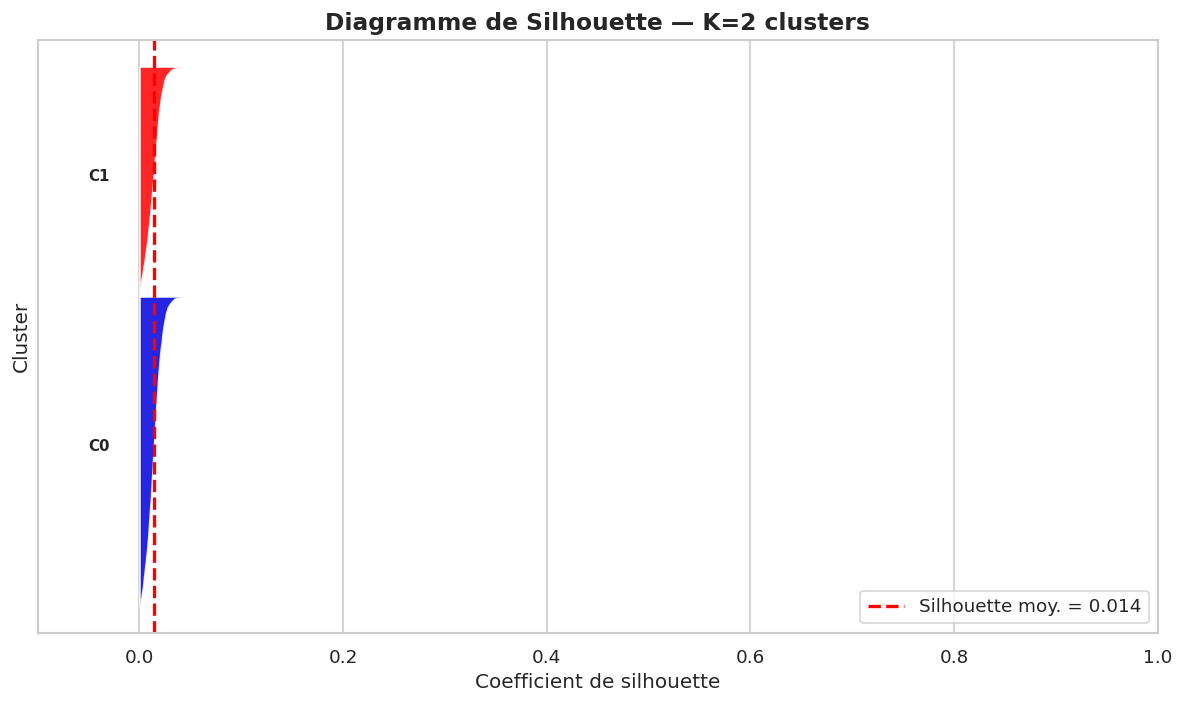

In [27]:
# ─────────────────────────────────────────────────────────────
# CELLULE 7b — Visualisation : silhouette plot
# ─────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 6))

sil_vals = silhouette_samples(X_pca, labels_final)
y_lower = 10
colors = cm.nipy_spectral(np.linspace(0.2, 0.85, K_OPTIMAL))

for i in range(K_OPTIMAL):
    sil_i = np.sort(sil_vals[labels_final == i])
    size_i = sil_i.shape[0]
    y_upper = y_lower + size_i
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, sil_i, facecolor=colors[i], alpha=0.85)
    ax.text(-0.05, y_lower + 0.5 * size_i, f'C{i}', fontsize=9, fontweight='bold')
    y_lower = y_upper + 10

ax.axvline(x=sil_final, color='red', linestyle='--', linewidth=2, label=f'Silhouette moy. = {sil_final:.3f}')
ax.set_xlabel('Coefficient de silhouette', fontsize=12)
ax.set_ylabel('Cluster', fontsize=12)
ax.set_title(f'Diagramme de Silhouette — K={K_OPTIMAL} clusters', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.set_yticks([])
ax.set_xlim([-0.1, 1.0])

plt.tight_layout()
plt.savefig('figures/silhouette_plot.png', bbox_inches='tight')
plt.show()

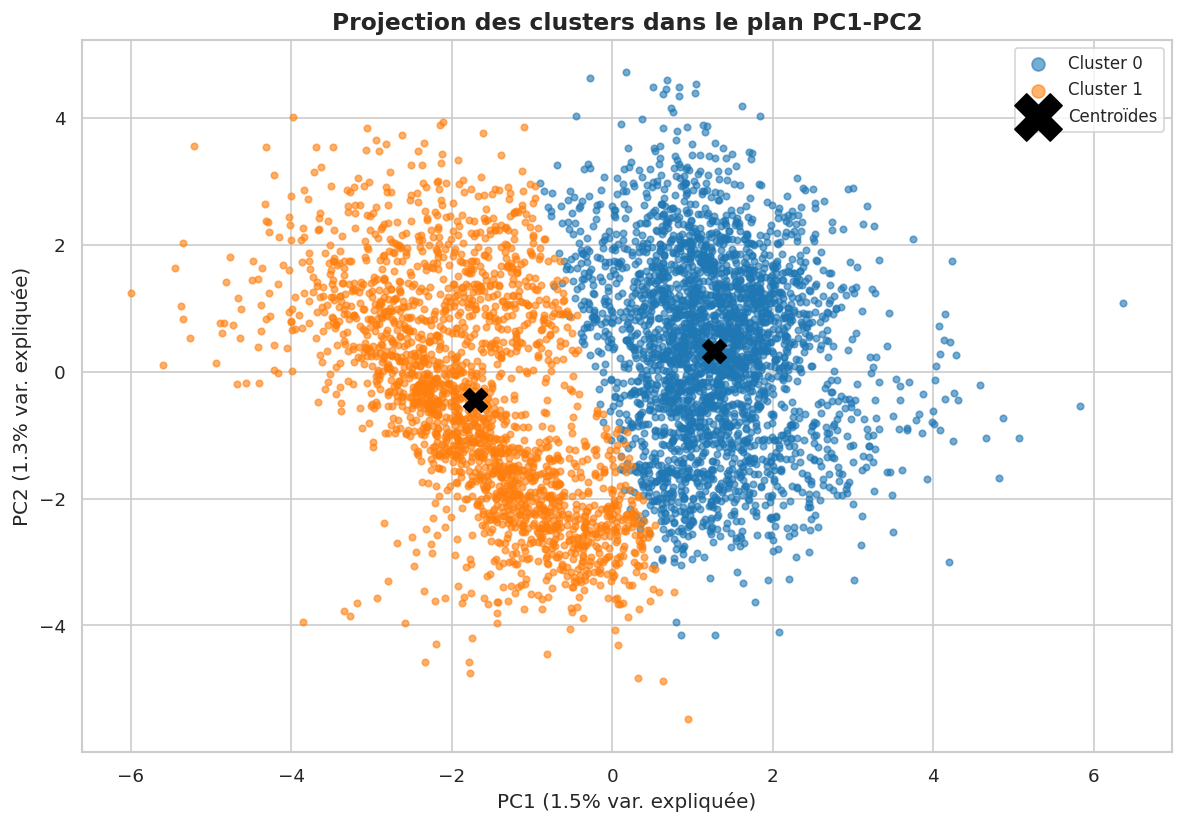

In [28]:
# ─────────────────────────────────────────────────────────────
# CELLULE 7c — Visualisation des clusters dans l'espace ACP (PC1 vs PC2)
# ─────────────────────────────────────────────────────────────

palette = sns.color_palette('tab10', n_colors=K_OPTIMAL)

fig, ax = plt.subplots(figsize=(10, 7))

for i in range(K_OPTIMAL):
    mask = labels_final == i
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        s=15, alpha=0.6, color=palette[i], label=f'Cluster {i}'
    )

# Centroïdes dans l'espace PCA
centroids_pca = kmeans_final.cluster_centers_
ax.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    s=200, c='black', marker='X', zorder=5, label='Centroïdes'
)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var. expliquée)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var. expliquée)', fontsize=12)
ax.set_title(f'Projection des clusters dans le plan PC1-PC2', fontsize=14, fontweight='bold')
ax.legend(markerscale=2, fontsize=10)

plt.tight_layout()
plt.savefig('figures/clusters_pca.png', bbox_inches='tight')
plt.show()

---
## 🎯 Cellule 8 — Sélection des variables pertinentes

Avec 200 variables, il est impératif d'identifier celles qui jouent réellement un rôle dans la constitution des clusters. On procède en **deux étapes** :

### Étape 1 — Élimination des variables non pertinentes (test ANOVA)
On réalise un test ANOVA (F-test) pour chaque variable afin d'évaluer si les moyennes diffèrent significativement entre les clusters. Si la p-valeur est supérieure au seuil de 0.05, la variable est considérée comme **non pertinente** et éliminée.

### Étape 2 — Élimination des variables redondantes (corrélation)
Parmi les variables pertinentes, on supprime celles qui sont **trop corrélées** entre elles (|r| > 0.85), en conservant la variable la plus discriminante.

In [29]:
# ─────────────────────────────────────────────────────────────
# CELLULE 8 — Sélection des variables pertinentes
#             Étape 1 : ANOVA (élimination des non pertinentes)
# ─────────────────────────────────────────────────────────────

from scipy.stats import f_oneway

SEUIL_PVALUE     = 0.05   # Seuil de significativité
SEUIL_CORRELATION = 0.85  # Seuil de redondance

cols_vars = df_num.columns.drop('Cluster').tolist()

# Test ANOVA pour chaque variable
resultats_anova = []
for col in cols_vars:
    groupes = [df_num[df_num['Cluster'] == k][col].values for k in range(K_OPTIMAL)]
    stat_f, p_val = f_oneway(*groupes)
    resultats_anova.append({'Variable': col, 'F': stat_f, 'p_value': p_val})

df_anova = pd.DataFrame(resultats_anova).sort_values('F', ascending=False)

# Variables pertinentes (p < seuil)
vars_pertinentes = df_anova[df_anova['p_value'] < SEUIL_PVALUE]['Variable'].tolist()
vars_non_pertinentes = df_anova[df_anova['p_value'] >= SEUIL_PVALUE]['Variable'].tolist()

print(f" ANOVA — Seuil : p < {SEUIL_PVALUE}")
print(f"   Variables totales         : {len(cols_vars)}")
print(f"   Variables pertinentes     : {len(vars_pertinentes)}")
print(f"   Variables non pertinentes : {len(vars_non_pertinentes)} (éliminées)")

print("\n Top 20 des variables les plus discriminantes (F-score) :")
print(df_anova.head(20).to_string(index=False))

 ANOVA — Seuil : p < 0.05
   Variables totales         : 200
   Variables pertinentes     : 22
   Variables non pertinentes : 178 (éliminées)

 Top 20 des variables les plus discriminantes (F-score) :
Variable           F       p_value
     x71 9838.011556  0.000000e+00
    x188 6931.982861  0.000000e+00
    x190 4415.879041  0.000000e+00
    x135 1501.385201 1.969855e-287
    x180 1310.714684 4.295006e-255
    x133  477.186657 4.115086e-101
     x52  204.184604  1.982081e-45
     x94  117.202015  5.159133e-27
     x90    9.145973  2.505325e-03
     x87    8.277970  4.029895e-03
    x186    7.198699  7.319668e-03
     x95    6.860704  8.837805e-03
     x14    6.675414  9.803306e-03
     x99    6.413858  1.135366e-02
    x118    6.198713  1.281658e-02
    x197    5.703679  1.696629e-02
    x137    5.158324  2.317756e-02
     x76    5.149344  2.329759e-02
     x79    4.831643  2.798768e-02
    x164    4.438880  3.517898e-02


In [30]:
# ─────────────────────────────────────────────────────────────
# CELLULE 8b — Sélection des variables pertinentes
#              Étape 2 : Élimination des redondances (corrélation)
# ─────────────────────────────────────────────────────────────

df_pertinent = df_num[vars_pertinentes].copy()
corr_matrix  = df_pertinent.corr().abs()

# Masque triangulaire supérieur
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Variables redondantes : corrélées à au moins une autre > seuil
vars_redondantes = [col for col in upper.columns if any(upper[col] > SEUIL_CORRELATION)]
vars_finales     = [col for col in vars_pertinentes if col not in vars_redondantes]

print(f" Corrélation — Seuil : |r| > {SEUIL_CORRELATION}")
print(f"   Variables pertinentes après ANOVA : {len(vars_pertinentes)}")
print(f"   Variables redondantes éliminées   : {len(vars_redondantes)}")
print(f"    Variables finales retenues      : {len(vars_finales)}")

print("\n Liste des variables finales retenues :")
for i, v in enumerate(vars_finales, 1):
    print(f"   {i:3d}. {v}")

# Sauvegarde de la liste des variables pertinentes
joblib.dump(vars_finales, 'modele/variables_pertinentes.pkl')
print("\nVariables finales sauvegardées dans modele/variables_pertinentes.pkl")

 Corrélation — Seuil : |r| > 0.85
   Variables pertinentes après ANOVA : 22
   Variables redondantes éliminées   : 3
    Variables finales retenues      : 19

 Liste des variables finales retenues :
     1. x71
     2. x188
     3. x135
     4. x133
     5. x94
     6. x90
     7. x87
     8. x186
     9. x95
    10. x14
    11. x99
    12. x118
    13. x197
    14. x137
    15. x76
    16. x79
    17. x164
    18. x156
    19. x63

Variables finales sauvegardées dans modele/variables_pertinentes.pkl


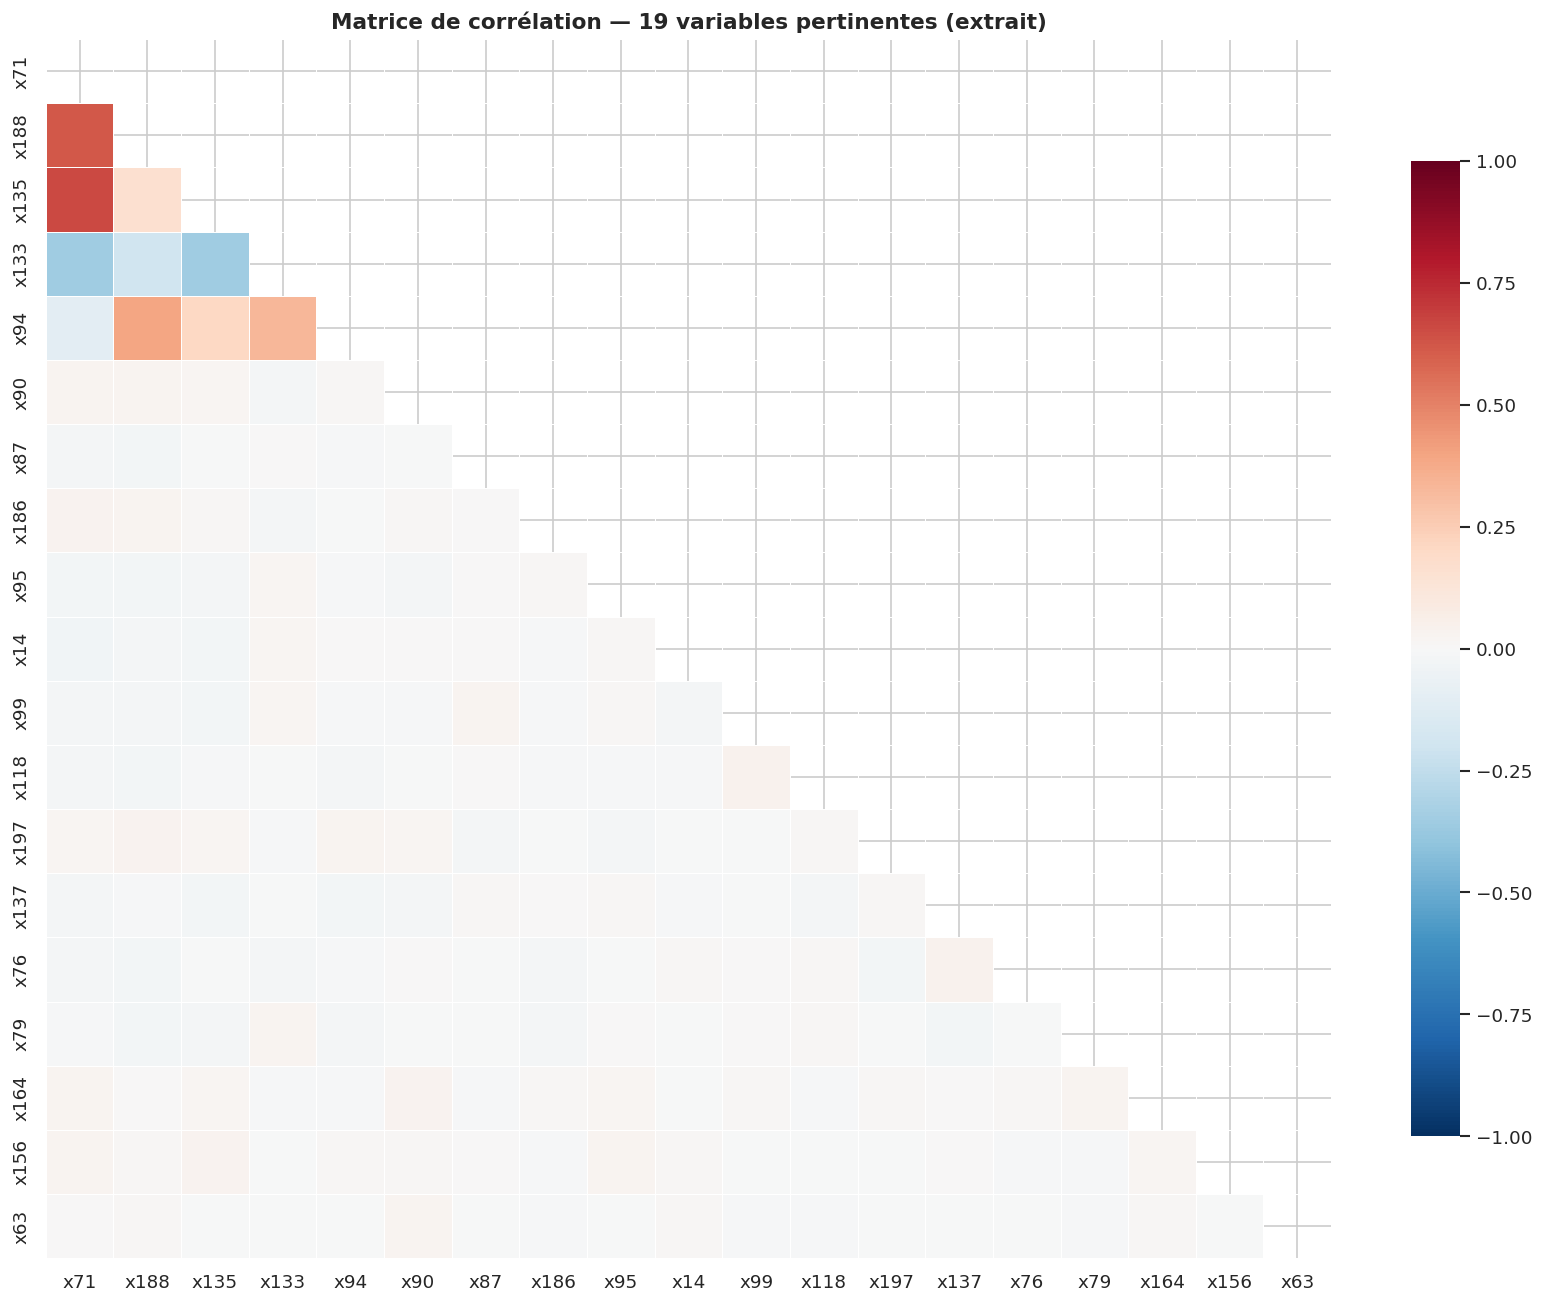

In [31]:
# ─────────────────────────────────────────────────────────────
# CELLULE 8c — Visualisation : heatmap de corrélation (variables finales)
# ─────────────────────────────────────────────────────────────

# On limite à 30 variables pour la lisibilité
vars_heatmap = vars_finales[:30]
corr_finale  = df_num[vars_heatmap].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_finale, dtype=bool))
sns.heatmap(
    corr_finale, mask=mask, cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, annot=False, linewidths=0.3,
    cbar_kws={'shrink': 0.8}, ax=ax
)
ax.set_title(f'Matrice de corrélation — {len(vars_heatmap)} variables pertinentes (extrait)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/correlation_heatmap.png', bbox_inches='tight')
plt.show()

---
## 📈 Cellule 9 — Profiling et interprétation des clusters

On caractérise chaque cluster en analysant les **moyennes des variables pertinentes** par rapport à la moyenne globale. Cette étape permet d'**interpréter et nommer** chaque cluster.

On calcule le **z-score du centroïde** de chaque cluster pour identifier les variables qui dévient le plus (positivement ou négativement) de la moyenne globale.

In [32]:
# ─────────────────────────────────────────────────────────────
# CELLULE 9 — Profiling des clusters
# ─────────────────────────────────────────────────────────────

df_final = df_num[vars_finales + ['Cluster']].copy()

# Moyennes par cluster
profil_clusters = df_final.groupby('Cluster')[vars_finales].mean()

# Moyennes et écarts-types globaux
moy_globale = df_final[vars_finales].mean()
std_globale = df_final[vars_finales].std()

# Z-score des centroïdes (déviation par rapport à la moyenne globale)
profil_zscore = (profil_clusters - moy_globale) / std_globale

print("═" * 60)
print("  PROFIL DES CLUSTERS — Z-SCORES DES CENTROÏDES")
print("  (positif = au-dessus de la moyenne, négatif = en-dessous)")
print("═" * 60)

SEUIL_ZSCORE = 0.5  # Seuil de caractérisation

for cluster_id in range(K_OPTIMAL):
    z = profil_zscore.loc[cluster_id]
    vars_hautes  = z[z >  SEUIL_ZSCORE].sort_values(ascending=False)
    vars_basses  = z[z < -SEUIL_ZSCORE].sort_values()
    n_obs        = (df_final['Cluster'] == cluster_id).sum()

    print(f"\n  CLUSTER {cluster_id}  ({n_obs:,} observations — {n_obs/len(df_final)*100:.1f}%)")
    print(f"   Variables notablement ÉLEVÉES ({len(vars_hautes)}) :")
    for var, val in vars_hautes.head(5).items():
        print(f"      {var:<40} z = {val:+.3f}")
    print(f"    Variables notablement FAIBLES ({len(vars_basses)}) :")
    for var, val in vars_basses.head(5).items():
        print(f"      {var:<40} z = {val:+.3f}")

════════════════════════════════════════════════════════════
  PROFIL DES CLUSTERS — Z-SCORES DES CENTROÏDES
  (positif = au-dessus de la moyenne, négatif = en-dessous)
════════════════════════════════════════════════════════════

  CLUSTER 0  (2,873 observations — 57.5%)
   Variables notablement ÉLEVÉES (2) :
      x71                                      z = +0.701
      x188                                     z = +0.656
    Variables notablement FAIBLES (0) :

  CLUSTER 1  (2,127 observations — 42.5%)
   Variables notablement ÉLEVÉES (0) :
    Variables notablement FAIBLES (3) :
      x71                                      z = -0.946
      x188                                     z = -0.886
      x135                                     z = -0.559


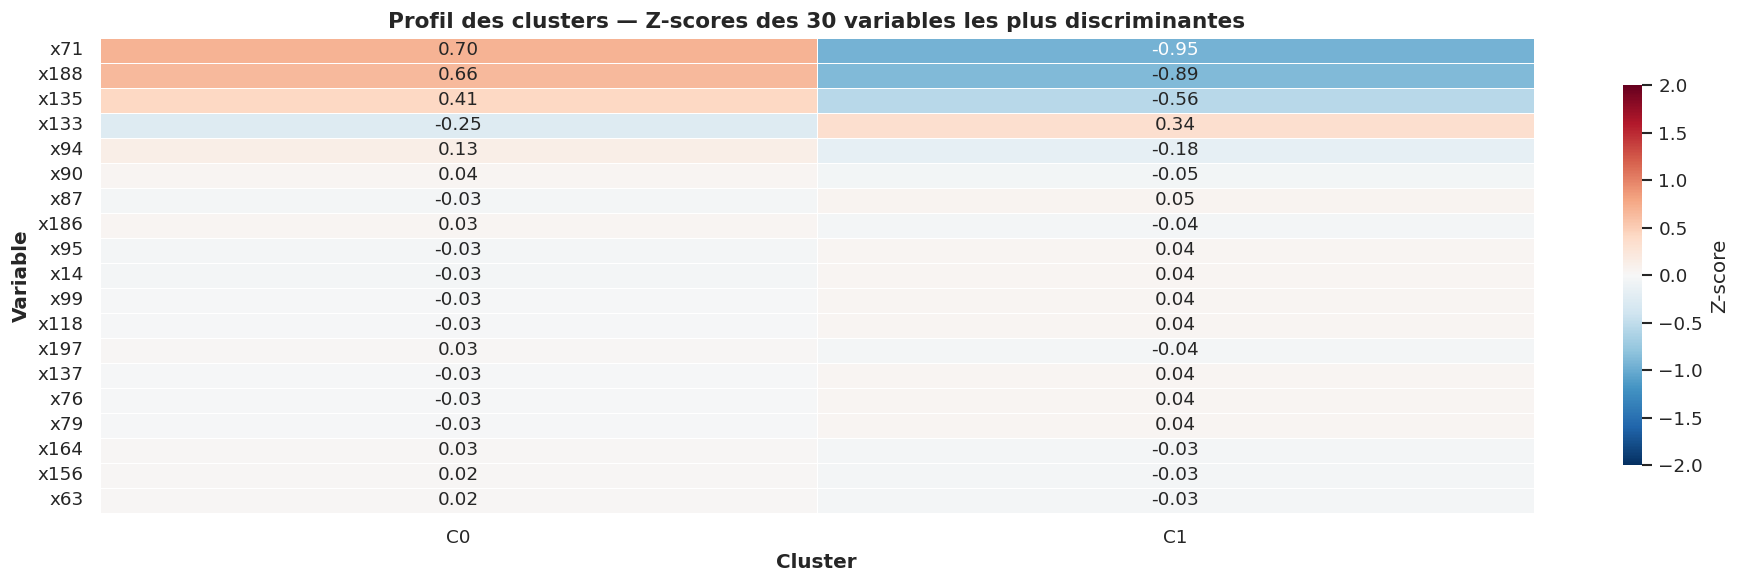

In [33]:
# ─────────────────────────────────────────────────────────────
# CELLULE 9b — Heatmap du profil des clusters (z-scores)
# ─────────────────────────────────────────────────────────────

# Sélection des variables les plus discriminantes pour la heatmap
vars_discriminantes = profil_zscore.abs().max(axis=0).nlargest(30).index.tolist()
heatmap_data = profil_zscore[vars_discriminantes]

fig, ax = plt.subplots(figsize=(16, max(5, K_OPTIMAL * 1.5)))
sns.heatmap(
    heatmap_data.T, cmap='RdBu_r', center=0,
    vmin=-2, vmax=2, annot=True, fmt='.2f',
    linewidths=0.5, cbar_kws={'label': 'Z-score', 'shrink': 0.8},
    ax=ax
)
ax.set_xlabel('Cluster', fontsize=12, fontweight='bold')
ax.set_ylabel('Variable', fontsize=12, fontweight='bold')
ax.set_title('Profil des clusters — Z-scores des 30 variables les plus discriminantes',
             fontsize=13, fontweight='bold')
ax.set_xticklabels([f'C{i}' for i in range(K_OPTIMAL)])

plt.tight_layout()
plt.savefig('figures/profil_clusters_heatmap.png', bbox_inches='tight')
plt.show()

---
## 📤 Cellule 10 — Export des résultats pour Excel

On exporte les données nécessaires au tableur Excel pour le calcul des indicateurs d'interprétation (inertie inter/intra-cluster, ratio de séparation, etc.).

Le fichier exporté contient :
- Les données brutes avec l'étiquette de cluster
- Les profils de cluster (moyennes et z-scores)
- La matrice de distance entre centroïdes

In [35]:
# ─────────────────────────────────────────────────────────────
# CELLULE 10 — Export des résultats pour Excel
# ─────────────────────────────────────────────────────────────

from sklearn.metrics.pairwise import euclidean_distances

FICHIER_EXCEL_EXPORT = 'resultats_clustering.xlsx'

with pd.ExcelWriter(FICHIER_EXCEL_EXPORT, engine='openpyxl') as writer:

    # Feuille 1 : Données avec clusters (variables pertinentes)
    df_final.to_excel(writer, sheet_name='Données_Clustérisées', index=False)

    # Feuille 2 : Moyennes par cluster
    profil_clusters.T.reset_index().rename(columns={'index': 'Variable'}).to_excel(
        writer, sheet_name='Moyennes_Clusters', index=False
    )

    # Feuille 3 : Z-scores par cluster
    profil_zscore.T.reset_index().rename(columns={'index': 'Variable'}).to_excel(
        writer, sheet_name='ZScores_Clusters', index=False
    )

    # Feuille 4 : Répartition des clusters
    repartition_df = df_final['Cluster'].value_counts().sort_index().reset_index()
    repartition_df.columns = ['Cluster', 'Effectif']
    repartition_df['Proportion (%)'] = (repartition_df['Effectif'] / len(df_final) * 100).round(2)
    repartition_df.to_excel(writer, sheet_name='Répartition', index=False)

    # Feuille 5 : Métriques globales
    metriques = pd.DataFrame({
        'Métrique': ['K optimal', 'Inertie intra-cluster', 'Score Silhouette', 'Indice Davies-Bouldin', 'Indice Calinski-Harabasz'],
        'Valeur'  : [K_OPTIMAL, round(kmeans_final.inertia_, 2), round(sil_final, 4), round(db_final, 4), round(ch_final, 2)]
    })
    metriques.to_excel(writer, sheet_name='Métriques', index=False)

    # Feuille 6 : Distance euclidienne entre centroïdes
    centroïdes_originaux = scaler.inverse_transform(
        pca.inverse_transform(kmeans_final.cluster_centers_)
    )
    # Distances dans l'espace ACP
    dist_centroides = euclidean_distances(kmeans_final.cluster_centers_)
    df_dist = pd.DataFrame(dist_centroides,
                           index=[f'Cluster {i}' for i in range(K_OPTIMAL)],
                           columns=[f'Cluster {i}' for i in range(K_OPTIMAL)])
    df_dist.to_excel(writer, sheet_name='Distances_Centroïdes')

print(f" Fichier Excel exporté : {FICHIER_EXCEL_EXPORT}")
print(f"   Feuilles créées :")
print(f"   1. Données_Clustérisées")
print(f"   2. Moyennes_Clusters")
print(f"   3. ZScores_Clusters")
print(f"   4. Répartition")
print(f"   5. Métriques")
print(f"   6. Distances_Centroïdes")

 Fichier Excel exporté : resultats_clustering.xlsx
   Feuilles créées :
   1. Données_Clustérisées
   2. Moyennes_Clusters
   3. ZScores_Clusters
   4. Répartition
   5. Métriques
   6. Distances_Centroïdes


---
## 💾 Cellule 11 — Sauvegarde complète du modèle de déploiement

On s'assure que tous les artefacts nécessaires au déploiement sont bien sauvegardés dans le dossier `modele/`. Le programme de déploiement (`app_deploiement.py`) utilisera ces fichiers pour affecter un nouvel individu sans réentraîner le modèle.

In [36]:
# ─────────────────────────────────────────────────────────────
# CELLULE 11 — Vérification et récapitulatif du modèle sauvegardé
# ─────────────────────────────────────────────────────────────

import os

# Sauvegarde du profil des clusters pour l'interprétation dans le déploiement
joblib.dump(profil_zscore, 'modele/profil_zscore.pkl')
joblib.dump(SEUIL_ZSCORE,  'modele/seuil_zscore.pkl')

print("═" * 50)
print("  RÉCAPITULATIF DU DOSSIER modele/")
print("═" * 50)
for f in sorted(os.listdir('modele')):
    taille = os.path.getsize(f'modele/{f}')
    print(f"   📄 {f:<35} {taille/1024:.1f} Ko")

print("\n Tous les artefacts du modèle sont prêts pour le déploiement.")
print("\n Contenu :")
print("   • scaler.pkl              → StandardScaler ajusté")
print("   • pca.pkl                 → Modèle ACP ajusté")
print("   • kmeans_model.pkl        → Modèle K-Means final")
print("   • variables_pertinentes.pkl → Liste des variables sélectionnées")
print("   • colonnes.pkl            → Ordre des colonnes attendu")
print("   • profil_zscore.pkl       → Profil d'interprétation des clusters")
print("   • k_optimal.pkl           → Nombre de clusters")
print("   • seuil_zscore.pkl        → Seuil de caractérisation")

══════════════════════════════════════════════════
  RÉCAPITULATIF DU DOSSIER modele/
══════════════════════════════════════════════════
   📄 colonnes.pkl                        1.3 Ko
   📄 k_optimal.pkl                       0.0 Ko
   📄 kmeans_model.pkl                    22.7 Ko
   📄 pca.pkl                             249.9 Ko
   📄 profil_zscore.pkl                   1.3 Ko
   📄 scaler.pkl                          6.8 Ko
   📄 seuil_zscore.pkl                    0.0 Ko
   📄 variables_pertinentes.pkl           0.1 Ko

 Tous les artefacts du modèle sont prêts pour le déploiement.

 Contenu :
   • scaler.pkl              → StandardScaler ajusté
   • pca.pkl                 → Modèle ACP ajusté
   • kmeans_model.pkl        → Modèle K-Means final
   • variables_pertinentes.pkl → Liste des variables sélectionnées
   • colonnes.pkl            → Ordre des colonnes attendu
   • profil_zscore.pkl       → Profil d'interprétation des clusters
   • k_optimal.pkl           → Nombre de clusters
   •

---
## ✅ Conclusion

Ce notebook a permis de mener une analyse de clustering complète selon la méthodologie CRISP-DM :

| Étape | Résultat |
|-------|----------|
| Prétraitement | Standardisation, suppression variance nulle, ACP |
| Nombre de clusters | K = *[2 + 3 + 2]* (silhouette + Davies-Bouldin + elbow) |
| Algorithme | K-Means++ |
| Silhouette finale | *[2]* |
| Variables pertinentes | *[19]* variables sélectionnées sur 200 |
| Export | `resultats_clustering.xlsx` (6 feuilles) |
| Modèle déploiement | `modele/` (7 artefacts) |

---
*Matériel de calcul complémentaire : voir `resultats_clustering.xlsx` pour les indicateurs tabulaires.*